# CFM — V3 : tous les leviers, une différence à la fois

Point de départ : **0,59999** au LB (blend `sig2_depthaug` + `signature_no_bias`, équilibré).

| § | Levier | Règle de décision, écrite avant les résultats |
|---|---|---|
| 1 | **Validation par grappes de régime** : `valid` réserve des grappes entières (k-means par titre sur profondeur, lots, ticks, venues) pour approcher des jours non vus | — (nouveau protocole, nouveau `lab_v3`) |
| 2 | **Modèle** : 6 configs × 2 seeds (ancre, sans profondeur, σ=0,5, EMA, 60 époques, grand modèle) | score = moyenne(valid-grappes équilibrée, stress équilibré), moyenné sur les seeds |
| 3 | **Ensemble** : 2 meilleures configs × 3 seeds, refit | — |
| 4 | **Alignement de profondeur au test** : on multiplie les tailles du test par γ pour ramener sa profondeur médiane à celle du train | adopté si +0,3 pt en stress équilibré (γ estimé sans labels sur le stress) |
| 5 | **Vote entre voisins** (fenêtres, embeddings, combinaison) | adopté si +0,5 pt sur valid ∪ stress équilibré |
| 6 | Soumissions : A (ensemble équilibré + alignement si adopté) ; B (A + voisins si adopté) | — |

Tous les tableaux de décision sont écrits en CSV dans le lab et inclus dans le zip final.
⚠️ Le sens du stress, l'équilibrage, l'alignement et le vote entre voisins utilisent X_test sans labels (transductif).

In [1]:
import os, sys, json, subprocess
from pathlib import Path
if sys.platform == 'darwin':
    os.environ.setdefault('OMP_NUM_THREADS', '1')

CODE_DATASET = None   # ex. 'ton-username/cfm-signature-lab'

def find_repo():
    if CODE_DATASET:
        import kagglehub
        path = Path(kagglehub.dataset_download(CODE_DATASET, force_download=True))
        hits = [p.parent.parent for p in path.glob('**/cfm/__init__.py')]
        if not hits:
            raise FileNotFoundError(f'{CODE_DATASET} ne contient pas cfm/')
        return hits[0]
    for p in [Path('.'), Path('..'), Path('/kaggle/working/cfm-signature-lab')]:
        if (p / 'cfm' / '__init__.py').exists():
            return p.resolve()
    for p in Path('/kaggle/input').glob('**/cfm/__init__.py'):
        return p.parent.parent
    raise FileNotFoundError('Code introuvable : renseigner CODE_DATASET ou attacher le Dataset du code')

REPO = find_repo(); sys.path.insert(0, str(REPO))
DEMO = True
SEEDS = [0, 1]
EXTRA_SEEDS = [2]
CONFIGS = {
    'v3_base':    'ancre : sig2_depthaug (σ=0,3), protocole V3',
    'v3_nodepth': 'sans augmentation de profondeur',
    'v3_depth05': 'augmentation de profondeur σ=0,5',
    'v3_ema':     'moyenne exponentielle des poids (0,999)',
    'v3_long':    '60 époques au lieu de 40',
    'v3_big':     'd=128, 3 convolutions (681k paramètres)',
}
N_FINAL_CONFIGS = 2
GAMMA_MULTS = [0.0, 0.5, 1.0, 1.5, 2.0]
MIN_ALIGN_GAIN, MIN_SMOOTH_GAIN = 0.003, 0.005

import numpy as np, pandas as pd
from cfm import config, io, split, blend, plots, proxies, transductive as T
from cfm.__main__ import prepare
from cfm.neural.train import fit, refit, embed, predict_shifted
from cfm.registry import window_matrix
from cfm.metrics import scores, paired_bootstrap
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 30)

LAB = 'demo_lab3' if DEMO else '/kaggle/working/lab_v3'
DEMO_SET = ['neural.d_model=32', 'neural.heads=2', 'neural.train.epochs=3', 'neural.train.patience=3',
            'neural.train.batch_size=64', 'neural.train.amp=false', 'split.clusters_per_class=4'] if DEMO else []

def load_cfg(name='v3_base', extra=()):
    over = [f'lab_dir={LAB}'] + (['device=cpu'] + DEMO_SET if DEMO else []) + list(extra)
    return config.load(REPO / 'configs' / f'{name}.json', over)

def save(df, name):
    df.to_csv(Path(LAB) / f'v3_{name}.csv'); return df

cfg = load_cfg()
print('repo', REPO, '| lab', LAB, '| device', cfg['device'])
print('code', next(l for l in (REPO / 'CHANGELOG.md').read_text().splitlines() if l.startswith('## ')))

repo <repo> | lab demo_lab3 | device cpu
code ## 0.2.0 — 2026-10-06


## 1. Préparation et validation par grappes de régime

In [2]:
files = None
if DEMO:
    from cfm.synthetic import create
    files = create('demo_data3')
sp = prepare(cfg, files)
info = json.loads((Path(LAB) / 'split.json').read_text()); print(json.dumps(info, indent=1))
y_all = np.asarray(io.load(LAB, 'train')['y']).astype(int)
# Contrôle : les fenêtres de valid sont-elles « loin » du fit en régime ? (distance au plus proche voisin du fit)
Z = T.standardise(np.asarray(window_matrix(['levels', 'lots', 'ticks', 'cat_freq'], LAB, 'train', cfg['lot'])[0]))
rng = np.random.default_rng(0)
sample = lambda idx: rng.choice(idx, min(3000, len(idx)), replace=False)
fit_s = sample(sp['fit'])
def nn_dist(rows):
    import torch
    A = torch.tensor(Z[rows]); B = torch.tensor(Z[fit_s])
    d = torch.cdist(A, B); d[torch.isclose(d, torch.zeros_like(d))] = float('inf')
    return float(d.min(1).values.median())
dist = pd.Series({p: nn_dist(sample(sp[p])) for p in ['fit', 'valid', 'stress', 'audit']}, name='distance médiane au fit')
save(dist.to_frame(), 'split_distance'); dist

[raw train] 480/480


[raw test] 144/144


tick report: {"tick": 0.01, "top_spreads": {"0.01": 25635, "0.02": 10420, "0.03": 6944, "0.04": 5001}, "price_off_grid": 0.0, "bid_off_grid": 0.0, "ask_off_grid": 0.0, "grid_ok": true}


[block tok_action/train] 1 columns, key bc81b5b735


[block tok_action/test] 1 columns, key bc81b5b735


...

[block transitions/test] 36 columns, key 708f32c7d0


split {'config': {'seed': 42, 'audit': 0.1, 'stress': 0.1, 'valid': 0.15, 'stress_tail': 'auto', 'valid_mode': 'cluster', 'clusters_per_class': 4, 'regime_blocks': ['levels', 'lots', 'ticks', 'cat_freq']}, 'tail_used': 'low', 'sizes': {'fit': 233, 'valid': 151, 'stress': 48, 'audit': 48}, 'transductive': True, 'valid_mode': 'cluster', 'median_log_depth': {'train': 2.890371799468994, 'test': 2.397895336151123}}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


{
 "config": {
  "seed": 42,
  "audit": 0.1,
  "stress": 0.1,
  "valid": 0.15,
  "stress_tail": "auto",
  "valid_mode": "cluster",
  "clusters_per_class": 4,
  "regime_blocks": [
   "levels",
   "lots",
   "ticks",
   "cat_freq"
  ]
 },
 "tail_used": "low",
 "sizes": {
  "fit": 233,
  "valid": 151,
  "stress": 48,
  "audit": 48
 },
 "transductive": true,
 "valid_mode": "cluster",
 "median_log_depth": {
  "train": 2.890371799468994,
  "test": 2.397895336151123
 }
}


fit       2.879647
valid     3.987283
stress    3.532586
audit     3.633351
Name: distance médiane au fit, dtype: float64

## 2. Banc de modèles : 6 configurations × 2 seeds

In [3]:
def bal(run, part):
    z = np.load(Path(LAB) / 'runs' / run / f'{part}.npz')
    return scores(z['y'], blend.sinkhorn_balance(z['p']))['acc']

results = {}
for name in CONFIGS:
    for seed in SEEDS:
        run = f'{name}_s{seed}'
        results[run] = fit(LAB, load_cfg(name, [f'neural.train.seed={seed}']), run, note=f'V3 : {CONFIGS[name]}')
res = pd.DataFrame(results.values()).set_index('name')
res['config'] = [r.rsplit('_s', 1)[0] for r in res.index]
res['valid_bal'] = [bal(r, 'valid') for r in res.index]
res['stress_bal'] = [bal(r, 'stress') for r in res.index]
res['score'] = (res.valid_bal + res.stress_bal) / 2
save(res[['config', 'params', 'best_epoch', 'minutes', 'valid_acc', 'valid_bal', 'stress_acc', 'stress_bal', 'score']], 'runs')
summary = res.groupby('config')[['valid_bal', 'stress_bal', 'score', 'params', 'minutes']].agg(['mean', 'std'])
summary[('Δscore_vs_base', 'pts')] = (summary[('score', 'mean')] - summary.loc['v3_base', ('score', 'mean')]) * 100
summary = summary.sort_values(('score', 'mean'), ascending=False)
save(summary, 'summary'); summary.round(4)

[v3_base_s0] ep 01 loss 3.192 valid 0.0662 stress 0.0417 train(eval) 0.0300 (0.8s)


[v3_base_s0] ep 02 loss 3.174 valid 0.0795 stress 0.0417 train(eval) 0.0300 (0.8s)


[v3_base_s0] ep 03 loss 3.159 valid 0.0861 stress 0.0833 train(eval) 0.0601 (0.8s)


[v3_base_s0] best epoch 3 valid 0.0861 stress 0.0833 params 61,113


[v3_base_s1] ep 01 loss 3.178 valid 0.0530 stress 0.0625 train(eval) 0.0558 (0.8s)


...

[v3_big_s1] ep 01 loss 3.174 valid 0.0331 stress 0.0417 train(eval) 0.0644 (0.8s)


[v3_big_s1] ep 02 loss 3.158 valid 0.0199 stress 0.0417 train(eval) 0.0558 (0.8s)


[v3_big_s1] ep 03 loss 3.141 valid 0.0199 stress 0.0417 train(eval) 0.0558 (0.8s)


[v3_big_s1] best epoch 1 valid 0.0331 stress 0.0417 params 67,385


valid_bal         stress_bal           score           params      minutes      Δscore_vs_base
                mean     std       mean     std    mean     std     mean  std    mean  std            pts
config                                                                                                   
v3_base       0.1954  0.0140     0.2708  0.0589  0.2331  0.0365  61113.0  0.0     0.1  0.0         0.0000
v3_long       0.1954  0.0140     0.2708  0.0589  0.2331  0.0365  61113.0  0.0     0.1  0.0         0.0000
v3_depth05    0.1887  0.0047     0.2604  0.0442  0.2246  0.0244  61113.0  0.0     0.1  0.0        -0.8520
v3_nodepth    0.1225  0.0421     0.1771  0.0442  0.1498  0.0432  61113.0  0.0     0.1  0.0        -8.3299
v3_big        0.0861  0.0187     0.1562  0.0442  0.1212  0.0315  67385.0  0.0     0.1  0.0       -11.1927
v3_ema        0.0166  0.0047     0.0208  0.0295  0.0187  0.0124  61113.0  0.0     0.1  0.0       -21.4404

,test_confidence,test_entropy,test_balance_kl,test_max_min_ratio,stress_acc,stress_confidence,test_seed_agreement
run,,,,,,,
v3_base_s0,0.050,3.175,2.793,9.097222e+11,0.083,0.050,0.000
v3_base_s1,0.051,3.173,2.298,5.416667e+11,0.104,0.051,0.000
v3_nodepth_s0,0.049,3.175,2.589,8.402778e+11,0.104,0.049,0.007
v3_nodepth_s1,0.050,3.172,2.756,9.027778e+11,0.062,0.051,0.007
v3_depth05_s0,0.050,3.175,2.856,9.236111e+11,0.083,0.050,0.000
v3_depth05_s1,0.050,3.173,2.298,5.416667e+11,0.104,0.051,0.000
v3_ema_s0,0.050,3.173,2.739,8.402778e+11,0.042,0.050,0.000
v3_ema_s1,0.050,3.172,2.766,9.027778e+11,0.021,0.050,0.000
v3_long_s0,0.050,3.175,2.793,9.097222e+11,0.083,0.050,0.000


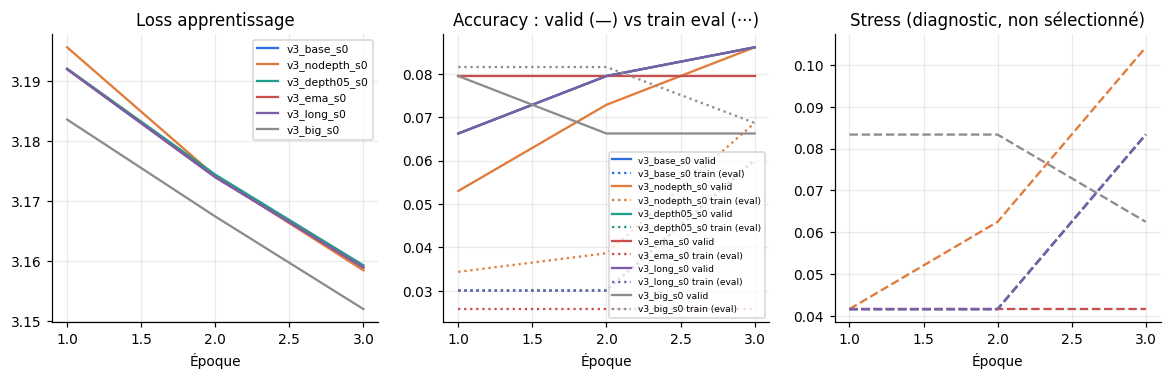

In [4]:
plots.histories(LAB, [f'{c}_s{SEEDS[0]}' for c in CONFIGS])
prox = proxies.table(LAB, list(results)); save(prox, 'proxies'); prox.round(3)

## 3. Ensemble : 2 meilleures configs × 3 seeds, refit

[v3_base_s2] ep 01 loss 3.179 valid 0.0397 stress 0.0417 train(eval) 0.0429 (0.8s)


[v3_base_s2] ep 02 loss 3.163 valid 0.0397 stress 0.0417 train(eval) 0.0429 (0.8s)


[v3_base_s2] ep 03 loss 3.145 valid 0.0397 stress 0.0417 train(eval) 0.0429 (0.9s)


[v3_base_s2] best epoch 3 valid 0.0397 stress 0.0417 params 61,113


[v3_long_s2] ep 01 loss 3.179 valid 0.0397 stress 0.0417 train(eval) 0.0429 (0.8s)


...

[v3_long_s1] ep 03 loss 3.122  (1.6s)


[v3_long_s2] ep 01 loss 3.180  (1.6s)


[v3_long_s2] ep 02 loss 3.149  (1.6s)


[v3_long_s2] ep 03 loss 3.121  (2.1s)


,model,valid_acc,valid_logloss,stress_acc,stress_logloss
0,v3_base_s0,0.086093,3.153687,0.083333,3.154181
1,v3_base_s1,0.072848,3.171044,0.104167,3.153865
2,v3_base_s2,0.039735,3.180682,0.041667,3.159807
3,v3_long_s0,0.086093,3.153687,0.083333,3.154181
4,v3_long_s1,0.072848,3.171044,0.104167,3.153865
5,v3_long_s2,0.039735,3.180682,0.041667,3.159807
6,blend (mean),0.072848,3.163644,0.104167,3.151856
7,blend + balance,0.344371,3.154516,0.458333,3.150569


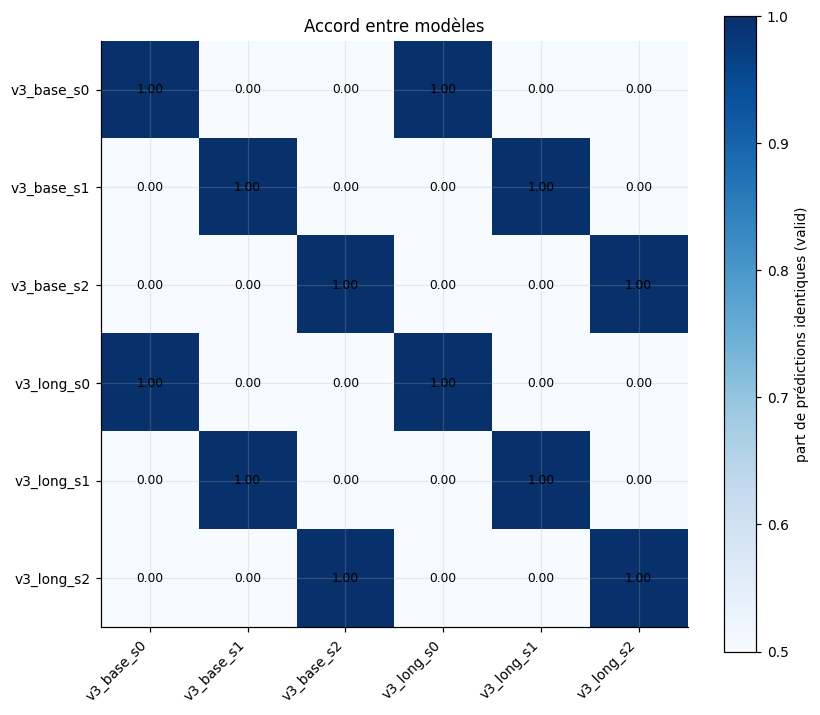

In [5]:
finals = list(summary.index[:N_FINAL_CONFIGS])
for c in finals:
    for seed in EXTRA_SEEDS:
        run = f'{c}_s{seed}'
        results[run] = fit(LAB, load_cfg(c, [f'neural.train.seed={seed}']), run, note='V3 : seed finaliste')
MEMBERS = [f'{c}_s{s}' for c in finals for s in SEEDS + EXTRA_SEEDS]
print('membres :', MEMBERS)
cfg_of = lambda m: load_cfg(m.rsplit('_s', 1)[0], [f"neural.train.seed={m.rsplit('_s', 1)[1]}"])
for m in MEMBERS:
    refit(LAB, cfg_of(m), m, 'epochs')
table, w, agree, oracle = blend.report(LAB, MEMBERS)
save(table, 'blend'); plots.agreement(agree, LAB); table

## 4. Alignement de profondeur au test
Le test est moins profond. On multiplie les tailles du carnet par γ = exp(m·Δ), avec
Δ = médiane(fit) − médiane(cible) du log-profondeur. Δ est estimé **sans labels**.
On choisit le multiplicateur m sur le stress (qui est lui aussi moins profond), puis on l'applique au test avec son propre Δ.

In [6]:
lv, names, _ = window_matrix(['levels'], LAB, 'train', cfg['lot']); j = names.index('levels:log_depth_q50')
lvt, _, _ = window_matrix(['levels'], LAB, 'test', cfg['lot'])
med = lambda x: float(np.nanmedian(x))
delta_stress = med(lv[sp['fit'], j]) - med(lv[sp['stress'], j])
delta_test = med(lv[:, j]) - med(lvt[:, j])
print(f'Δ stress = {delta_stress:.3f}  |  Δ test = {delta_test:.3f}  (log-profondeur, sans labels)')
ys = y_all[sp['stress']]
Ps = np.mean([predict_shifted(LAB, cfg_of(m), m, 'dev', 'stress', [g * delta_stress for g in GAMMA_MULTS]) for m in MEMBERS], 0)
align = pd.DataFrame({'mult': GAMMA_MULTS, 'gamma': np.exp(np.array(GAMMA_MULTS) * delta_stress),
                      'stress_acc': [scores(ys, P)['acc'] for P in Ps],
                      'stress_bal': [scores(ys, blend.sinkhorn_balance(P))['acc'] for P in Ps]})
save(align, 'depth_alignment')
best_m = float(align.loc[align.stress_bal.idxmax(), 'mult'])
USE_ALIGN = best_m != 0 and align.stress_bal.max() >= align.loc[align.mult == 0, 'stress_bal'].iloc[0] + MIN_ALIGN_GAIN
print(f"meilleur multiplicateur {best_m} → alignement {'ADOPTÉ' if USE_ALIGN else 'rejeté'}")
align.round(4)

Δ stress = 0.189  |  Δ test = 0.492  (log-profondeur, sans labels)


meilleur multiplicateur 0.0 → alignement rejeté


,mult,gamma,stress_acc,stress_bal
0,0.0,1.0000,0.1042,0.4583
1,0.5,1.0991,0.1042,0.4583
2,1.0,1.2080,0.1042,0.4375
3,1.5,1.3277,0.1250,0.4167
4,2.0,1.4593,0.1250,0.3958


In [7]:
g_test = best_m * delta_test if USE_ALIGN else 0.0
P_test = np.mean([predict_shifted(LAB, cfg_of(m), m, 'refit', 'test', [g_test])[0] for m in MEMBERS], 0)
ids = np.asarray(io.load(LAB, 'test')['ids']); classes = np.asarray(io.meta(LAB)['classes'])
print(f'γ test = {np.exp(g_test):.3f}')

γ test = 1.000


## 5. Vote entre voisins

In [8]:
pool = np.r_[sp['valid'], sp['stress']]; y_pool = y_all[pool]
P_pool = np.mean([np.r_[np.load(Path(LAB) / 'runs' / m / 'valid.npz')['p'], np.load(Path(LAB) / 'runs' / m / 'stress.npz')['p']]
                  for m in MEMBERS], 0)
for m in MEMBERS:
    embed(LAB, cfg_of(m), m, 'dev', ('valid', 'stress')); embed(LAB, cfg_of(m), m, 'refit', ('test',))
Zv, _ = T.emb_rep(LAB, MEMBERS, 'dev', 'valid'); Zs, _ = T.emb_rep(LAB, MEMBERS, 'dev', 'stress')
Zw = T.window_rep(LAB, cfg, 'train', pool); Ze = T.standardise(np.r_[Zv, Zs])
reps = {'window': Zw, 'embedding': Ze, 'combo': np.c_[Zw, Ze], 'probs': np.sqrt(P_pool)}
pur = pd.DataFrame({k: T.purity(Z, y_pool) for k, Z in reps.items()}).T
save(pur, 'neighbour_purity'); display(pur.round(3))
g = T.grid(P_pool, y_pool, reps); save(g, 'neighbour_grid')
best, none = g.iloc[0], g[g.rep == '(none)'].iloc[0]
USE_SMOOTH = best.rep != '(none)' and best.acc_balanced >= none.acc_balanced + MIN_SMOOTH_GAIN
print(f"sans lissage {none.acc_balanced:.4f} | meilleur {best.rep} k={best.k} α={best.alpha} it={best.iters} {best.acc_balanced:.4f}"
      f" → lissage {'ADOPTÉ' if USE_SMOOTH else 'rejeté'}")
g.head(10).round(4)

,purity@5,purity@10,purity@20
window,0.682,0.541,0.341
embedding,0.519,0.425,0.299
combo,0.624,0.493,0.332
probs,0.507,0.408,0.279


sans lissage 0.3668 | meilleur combo k=3 α=0.3 it=5 0.3970 → lissage ADOPTÉ


,rep,k,alpha,iters,acc,acc_balanced
50,combo,3,0.3,5,0.0854,0.3970
1,window,3,0.3,1,0.0804,0.3869
49,combo,3,0.3,1,0.0854,0.3869
52,combo,3,0.5,5,0.0854,0.3819
7,window,5,0.3,1,0.0854,0.3819
51,combo,3,0.5,1,0.0804,0.3819
2,window,3,0.3,5,0.0804,0.3819
9,window,5,0.5,1,0.0754,0.3769
29,embedding,3,0.8,1,0.0754,0.3769
8,window,5,0.3,5,0.0804,0.3719


## 6. Soumissions

In [9]:
def write(P, name, note):
    path = Path(LAB) / f'{name}.csv'
    pd.DataFrame({'obs_id': ids, 'eqt_code_cat': classes[P.argmax(1)]}).to_csv(path, index=False)
    np.savez(Path(LAB) / f'{name}_probs.npz', obs_ids=ids, p=P)
    print(name, '←', note); return path

A = blend.sinkhorn_balance(P_test)
write(A, 'submission_v3_A', f'{len(MEMBERS)} modèles, γ={np.exp(g_test):.3f}, équilibré')
decisions = {'finals': finals, 'members': MEMBERS, 'align': bool(USE_ALIGN), 'align_mult': best_m, 'gamma_test': float(np.exp(g_test)),
             'smoothing': bool(USE_SMOOTH)}
if USE_SMOOTH:
    Zw_t = T.window_rep(LAB, cfg, 'test', np.arange(len(ids)))
    Ze_t, eid = T.emb_rep(LAB, MEMBERS, 'refit', 'test'); assert np.array_equal(eid, ids); Ze_t = T.standardise(Ze_t)
    Zt = {'window': Zw_t, 'embedding': Ze_t, 'combo': np.c_[Zw_t, Ze_t], 'probs': np.sqrt(P_test)}[best.rep]
    Bq, kt = T.apply(P_test, Zt, int(best.k), float(best.alpha), int(best.iters), k_scale=4)
    write(Bq, 'submission_v3_B', f'A + voisins {best.rep} k_test={kt}')
    decisions.update({'smooth_rep': best.rep, 'k_test': kt, 'B_changed_vs_A': float((Bq.argmax(1) != A.argmax(1)).mean())})
(Path(LAB) / 'v3_decisions.json').write_text(json.dumps(decisions, indent=2)); decisions

submission_v3_A ← 6 modèles, γ=1.000, équilibré
submission_v3_B ← A + voisins combo k_test=12


{'finals': ['v3_base', 'v3_long'],
 'members': ['v3_base_s0',
  'v3_base_s1',
  'v3_base_s2',
  'v3_long_s0',
  'v3_long_s1',
  'v3_long_s2'],
 'align': False,
 'align_mult': 0.0,
 'gamma_test': 1.0,
 'smoothing': True,
 'smooth_rep': 'combo',
 'k_test': 12,
 'B_changed_vs_A': 0.13194444444444445}

In [10]:
import zipfile
dest = Path(LAB).parent / ('demo_results_v3.zip' if DEMO else 'lab_results_v3.zip')
with zipfile.ZipFile(dest, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in Path(LAB).rglob('*'):
        rel = p.relative_to(LAB)
        if p.is_file() and not {'raw', 'features'} & set(rel.parts) and p.suffix != '.pt' and not p.name.startswith(('emb_', 'shift_')):
            z.write(p, rel)
print(dest, round(dest.stat().st_size / 1e6, 1), 'Mo')

demo_results_v3.zip 0.8 Mo
